# CheXagent Playground


In [1]:
import os
import pandas as pd
import random
import warnings
from PIL import Image
from dotenv import load_dotenv
from rich import pretty, print, traceback, inspect

os.environ["TRANSFORMERS_VERBOSITY"] = "error"  # Suppress transformer warnings
warnings.filterwarnings("ignore")
# warnings.filterwarnings("ignore", category=UserWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)
traceback.install()
pretty.install()
load_dotenv()

False

In [2]:
positive_class = "Pneumonia"

## Load data


In [3]:
from datasets import load_dataset, Dataset

dataset_name = "nclgbd/mimic-cxr-findings-impressions"
data_path = "/home/nicoleg/physionet.org/files/mimic-cxr-jpg/2.0.0"
train_ds: Dataset = load_dataset(dataset_name, split="train")
val_ds: Dataset = load_dataset(dataset_name, split="validate")
test_ds: Dataset = load_dataset(dataset_name, split="test")
val_ds


Dataset({
    features: ['split', 'study_id', 'image_files', 'multiclass_labels', 'findings', 'impressions', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices', 'reports', 'biomed-clip-finetuned-embeddings', 'xrv-embeddings', 'dicom_id'],
    num_rows: 1557
})

['Lung Opacity', 'Pneumothorax', 'Support Devices']

FINAL REPORT
 EXAMINATION:  CHEST (PORTABLE AP)
 
 INDICATION:  ___M w/COPD, intubated, please eval for interval change  // ___M
 w/COPD, intubated, please eval for interval change      ___M w/COPD, intubated,
 please eval for interval change
 
 COMPARISON:  Comparison to ___ at 03:36
 
 FINDINGS: 
 
 Portable semi supine chest radiograph ___ 04:13 is submitted.
 
 IMPRESSION: 
 
 Again seen is extensive emphysema with prominent bullous changes particularly
 at the bases.  However, there is increased lucency at the left base with
 slight elevation of the left hemidiaphragm as well as increasing infrahilar
 opacity.  Findings therefore raise the possibility of a loculated
 pneumothorax.  Followup imaging is recommended.
 
 Endotracheal tube has its tip approximately 6 cm above the carina.  A left
 subclavian PICC line has its tip in the distal SVC near the cavoatrial
 junction and a nasogastric tube is seen coursing below the diaphragm with the
 tip not identified.  No pulmonary edema.
 
 NOTIFICATION:  Results were communicated to the patient's nurse, ___, on
 ___ at 12:08 at the time of discovery.

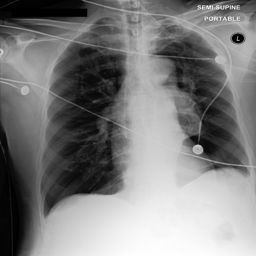

In [4]:
sample = random.choice(val_ds)
image_file = os.path.join(data_path, sample["image_files"])
print(sample["multiclass_labels"])
print(sample["reports"])
images = [Image.open(image_file).convert("RGB")]
images[0].resize((256, 256))

## Load model


In [5]:
from model_chexagent.chexagent import CheXagent

chexagent = CheXagent()

2025-05-10 08:53:44.016319: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-10 08:53:44.019455: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-10 08:53:44.026668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746892424.041435 2371956 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746892424.045824 2371956 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746892424.057311 2371956 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [6]:
val_ds


Dataset({
    features: ['split', 'study_id', 'image_files', 'multiclass_labels', 'findings', 'impressions', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices', 'reports', 'biomed-clip-finetuned-embeddings', 'xrv-embeddings', 'dicom_id'],
    num_rows: 1557
})

In [7]:
import re

findings_impressions = " ".join([sample["findings"], sample["impressions"]]).strip()
findings_impressions = re.sub(r"\s+", " ", findings_impressions)
print(findings_impressions)

Portable semi supine chest radiograph ___ 04:13 is submitted. Again seen is extensive emphysema with prominent 
bullous changes particularly at the bases. However, there is increased lucency at the left base with slight 
elevation of the left hemidiaphragm as well as increasing infrahilar opacity. Findings therefore raise the 
possibility of a loculated pneumothorax. Followup imaging is recommended. Endotracheal tube has its tip 
approximately 6 cm above the carina. A left subclavian PICC line has its tip in the distal SVC near the cavoatrial 
junction and a nasogastric tube is seen coursing below the diaphragm with the tip not identified. No pulmonary 
edema. NOTIFICATION: Results were communicated to the patient's nurse, ___, on ___ at 12:08 at the time of 
discovery.

In [8]:
query = f"Considering this patient's chest xray and radiology report summary:\n---\n{findings_impressions}\n---\nDoes this patient have {positive_class}?"
print(query)

Considering this patient's chest xray and radiology report summary:
---
Portable semi supine chest radiograph ___ 04:13 is submitted. Again seen is extensive emphysema with prominent 
bullous changes particularly at the bases. However, there is increased lucency at the left base with slight 
elevation of the left hemidiaphragm as well as increasing infrahilar opacity. Findings therefore raise the 
possibility of a loculated pneumothorax. Followup imaging is recommended. Endotracheal tube has its tip 
approximately 6 cm above the carina. A left subclavian PICC line has its tip in the distal SVC near the cavoatrial 
junction and a nasogastric tube is seen coursing below the diaphragm with the tip not identified. No pulmonary 
edema. NOTIFICATION: Results were communicated to the patient's nurse, ___, on ___ at 12:08 at the time of 
discovery.
---
Does this patient have Pneumonia?

In [9]:
kwargs = {
    "do_sample": False,
    "num_beams": 1,
    "temperature": 1.0,
    "top_p": 1.0,
    "use_cache": False,
    "max_new_tokens": 512,
    # "output_attentions": True,
    # "output_hidden_states": True,
    # "return_dict": False,
}
response = chexagent.generate([image_file], query)
print(response)

No

## Generate findings/impressions


## Classification based on findings


In [10]:
from tqdm import tqdm

results_path = "baseline_results/chexagent_results.csv"
keymap = {"yes": 1, "no": 0}
evaluate = False
if evaluate:
    results = {}
    for sample in tqdm(test_ds):
        image_file = os.path.join(data_path, sample["image_files"])
        findings_impressions = " ".join(
            [sample["findings"], sample["impressions"]]
        ).strip()
        findings_impressions = re.sub(r"\s+", " ", findings_impressions)
        query = f"Considering this patient's chest xray and radiology report summary:\n---\n{findings_impressions}\n---\nDoes this patient have {positive_class}?"
        response = chexagent.generate([image_file], query).lower().strip()
        results[sample["dicom_id"]] = {
            "y_pred": keymap[response],
            "y_true": sample[positive_class],
            "text": findings_impressions,
        }

    result_df = pd.DataFrame.from_dict(results, orient="index")
    result_df.index.name = "dicom_id"
    result_df.to_csv(results_path, index=True)
else:
    result_df = pd.read_csv(results_path, index_col="dicom_id")
result_df.sample(5)

,y_pred,y_true,text
dicom_id,,,
c3827619-5b104baa-e1895045-007f9978-837ef55e,0,0,The heart is normal in size. The aortic arch i...
9fe1d7c8-517e71cd-ac942a65-345092b2-8bbb82c0,1,0,"As compared to the previous radiograph, the pa..."
016991da-a5224d79-0a00be4e-485841d2-f9e917e8,0,0,"As compared to the previous radiograph, there ..."
fc346a9c-a6343b2b-98bdb36b-5a813740-aa659cba,0,0,A right internal jugular central venous cathet...
6a7b83c9-7b7c6ba9-09d85de8-a76f1aa7-4fd0e047,1,1,The patient is status post sternotomy and both...


In [104]:
from sklearn.metrics import classification_report, confusion_matrix
from tabulate import tabulate

target_names = ["No Pneumonia", "Pneumonia"]
y_true = result_df["y_true"].tolist()
y_pred = result_df["y_pred"].tolist()

# Classification report
cr_string = classification_report(y_true, y_pred, target_names=target_names)
cr = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
print("Classification Report:")
print(cr_string)

# Confusion matrix
print("Confusion Matrix:")
cfm = confusion_matrix(y_true, y_pred)
print(
    tabulate(cfm, headers=target_names, showindex=target_names, tablefmt="rounded_grid")
)

Classification Report:

precision    recall  f1-score   support

No Pneumonia       0.95      0.88      0.91      2388
   Pneumonia       0.38      0.61      0.47       294

    accuracy                           0.85      2682
   macro avg       0.66      0.74      0.69      2682
weighted avg       0.89      0.85      0.86      2682

Confusion Matrix:

╭──────────────┬────────────────┬─────────────╮
│              │   No Pneumonia │   Pneumonia │
├──────────────┼────────────────┼─────────────┤
│ No Pneumonia │           2094 │         294 │
├──────────────┼────────────────┼─────────────┤
│ Pneumonia    │            115 │         179 │
╰──────────────┴────────────────┴─────────────╯

In [107]:
summary = pd.DataFrame(
    {
        "f1-score": round(cr["macro avg"]["f1-score"], 4),
        # "roc auc": round(roc_auc_score(y_true, y_pred), 4),
        "sensitivity": round(cr["Pneumonia"]["recall"], 4),
        "specificity": round(cr["No Pneumonia"]["recall"], 4),
        "recall": round(cr["macro avg"]["recall"], 4),
        "precision": round(cr["macro avg"]["precision"], 4),
        "accuracy": round(cr["accuracy"], 4),
    },
    index=["chexagent"],
)
summary

,f1-score,sensitivity,specificity,recall,precision,accuracy
chexagent,0.6889,0.6088,0.8769,0.7429,0.6632,0.8475


### Filtered results


In [112]:
filtered_data = "/home/nicoleg/workspaces/dissertation/notebooks/results/mini-internvl2-1b-da-medical_response_df.csv"
llm_resp = pd.read_csv(filtered_data).set_index("dicom_id")
llm_resp = llm_resp[llm_resp["mimic_labels"] == llm_resp["llm_responses"]]
test_df = test_ds.to_pandas().set_index("dicom_id")

In [ ]:
indices = list(set(llm_resp.index).intersection(set(test_df.index.values)))

In [118]:
fdf = result_df.loc[indices]
y_pred = fdf["y_pred"].tolist()
y_true = fdf["y_true"].tolist()

In [119]:
# Classification report
cr_string = classification_report(y_true, y_pred, target_names=target_names)
cr = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
print("Classification Report:")
print(cr_string)

# Confusion matrix
print("Confusion Matrix:")
cfm = confusion_matrix(y_true, y_pred)
print(
    tabulate(cfm, headers=target_names, showindex=target_names, tablefmt="rounded_grid")
)

Classification Report:

precision    recall  f1-score   support

No Pneumonia       0.96      0.92      0.94      1731
   Pneumonia       0.53      0.71      0.61       234

    accuracy                           0.89      1965
   macro avg       0.75      0.81      0.77      1965
weighted avg       0.91      0.89      0.90      1965

Confusion Matrix:

╭──────────────┬────────────────┬─────────────╮
│              │   No Pneumonia │   Pneumonia │
├──────────────┼────────────────┼─────────────┤
│ No Pneumonia │           1587 │         144 │
├──────────────┼────────────────┼─────────────┤
│ Pneumonia    │             69 │         165 │
╰──────────────┴────────────────┴─────────────╯

In [120]:
summary = pd.DataFrame(
    {
        "f1-score": round(cr["macro avg"]["f1-score"], 4),
        # "roc auc": round(roc_auc_score(y_true, y_pred), 4),
        "sensitivity": round(cr["Pneumonia"]["recall"], 4),
        "specificity": round(cr["No Pneumonia"]["recall"], 4),
        "recall": round(cr["macro avg"]["recall"], 4),
        "precision": round(cr["macro avg"]["precision"], 4),
        "accuracy": round(cr["accuracy"], 4),
    },
    index=["filtered"],
)
summary

,f1-score,sensitivity,specificity,recall,precision,accuracy
filtered,0.7724,0.7051,0.9168,0.811,0.7462,0.8916


## Error Analysis


Filter:   0%|          | 0/1557 [00:00<?, ? examples/s]

WET READ: ___ ___ ___ 9:52 PM
  Low lung volumes, with no evidence of focal pneumonia.
 ______________________________________________________________________________
                                 FINAL REPORT
 PORTABLE CHEST, ___
 
 COMPARISON:  ___ chest radiograph and CT chest of ___.
 
 FINDINGS:  Peripheral right upper lobe lung nodule has grown compared to the
 prior CT chest of ___ and chest radiograph of ___.  On
 the prior chest radiograph, it measured 1.6 cm in diameter and now measures
 1.9 cm.  As AP technique may magnify the nodule, dedicated chest CT may be
 considered for more accurate assessment of interval growth as well as possible
 development of lymphadenopathy in the right hilum.  Heart remains enlarged. 
 Low lung volumes accentuate the pulmonary vascular structures.  Minor
 bibasilar atelectasis is present.  No definite pleural effusion.  Single-lead
 pacer remains in place, with lead terminating in right ventricle.
 
 IMPRESSION:
 1.  Slowly growing peripheral right upper lobe lung nodule is concerning for
 primary lung adenocarcinoma.  Dedicated chest CT may be considered for more
 accurate assessment as well as to evaluate for possible right hilar lymph node
 enlargement warranted clinically.
 2.  Low lung volumes limit assessment of the lung bases for pneumonia.  Given
 clinical suspicion for this entity, this could be further evaluated with
 repeat chest radiograph with improved inspiratory level. Dr. ___ was paged
 with these results at 8:15 a.m. on ___, at the time of discovery.

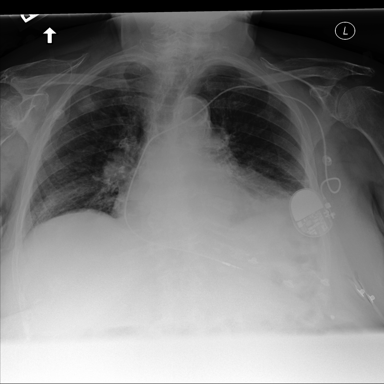

In [ ]:
eval_sample = val_ds.filter(
    lambda x: x["dicom_id"] == "da4b16dc-70fac17f-f55577e8-6d7eb687-7777fa17"
)[0]
print(eval_sample["reports"])
Image.open(os.path.join(data_path, eval_sample["image_files"])).convert("RGB").resize(
    (384, 384)
)